## Lab 2 - ML
### Imports

In [34]:
import torch
import torchvision
import torchcam
import json
import matplotlib.pyplot as plt
from torchvision.io import decode_image
from torchvision.models import get_model, get_model_weights
from torchvision.transforms.v2.functional import to_pil_image
from torchcam.methods import LayerCAM
from torchcam.utils import overlay_mask

print(torch.__version__)
print(torchvision.__version__)
print(torchcam.__version__)
print("CUDA available:", torch.cuda.is_available())

2.6.0+cu124
0.21.0+cu124
0.3.1
CUDA available: True


### LOading model

In [35]:
weights = get_model_weights("resnet50").DEFAULT
model = get_model("resnet50", weights=weights).eval().to("cuda")

print("Model loaded")

Model loaded


### Loading Class Index

In [36]:
with open("imagenet_class_index.json", "r") as f:
    class_index = json.load(f)

print("Total classes:", len(class_index))

Total classes: 1000


### Checking indexes for positive examples
here I will just collect the index numbers of the classes I want to check

In [49]:
for idx, values in class_index.items():
    if values[1] == "admiral":
        print(f"Admiral butterfly index: {idx}")
    if values[1] == "stingray":
        print(f"Stingray index: {idx}")
    if values[1] == "coral_reef":
        print(f"Coral Reef index: {idx}")

Stingray index: 6
Admiral butterfly index: 321
Coral Reef index: 973


### Prediction function

In [37]:
def predict(probs): 
    index = probs.argmax().item()
    name = class_index[str(index)][1]
    confidence = probs[index].item()
    return name, confidence

### CAM pipeline function

In [38]:
def run_cam(filename, layer, target_class=None):
    img = decode_image(filename)
    preprocess = weights.transforms()
    input_tensor = preprocess(img)
    batch_cuda = input_tensor.unsqueeze(0).to("cuda")
    
    cam_extractor = LayerCAM(model, target_layer=layer)
    output = model(batch_cuda)
    probs = torch.softmax(output.squeeze(0), dim=0)
    class_idx = target_class if target_class is not None else probs.argmax().item()
    activation_map = cam_extractor(class_idx, output)
    
    pil_img = to_pil_image(img)
    pil_map = to_pil_image(activation_map[0].squeeze(0), mode='F')
    result = overlay_mask(pil_img, pil_map, alpha=0.5)
    
    plt.imshow(result)
    plt.axis('off')
    plt.title(f"Predicted: {class_index[str(class_idx)][1]} ({probs[class_idx].item():.2%})")
    plt.tight_layout()
    plt.show()

### Running the analysis

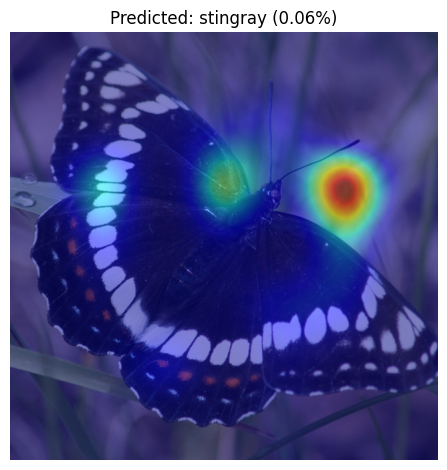

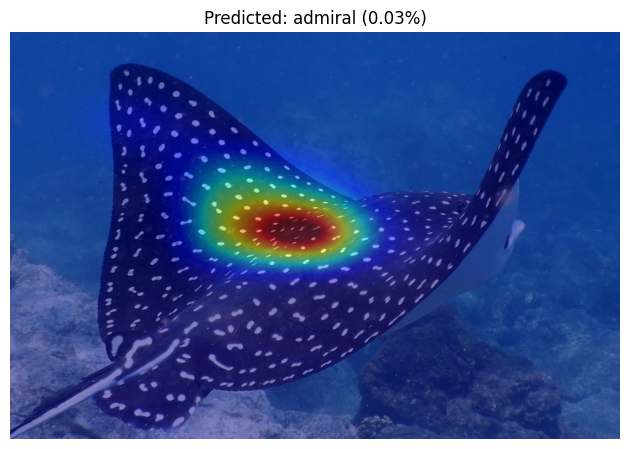

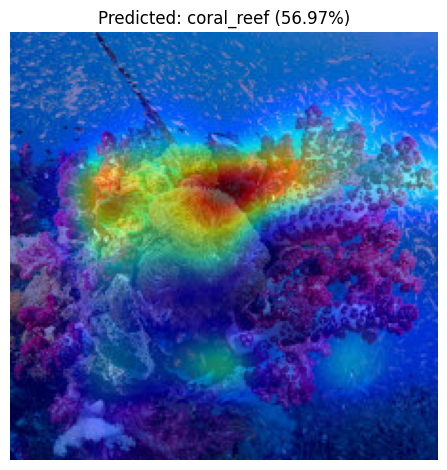

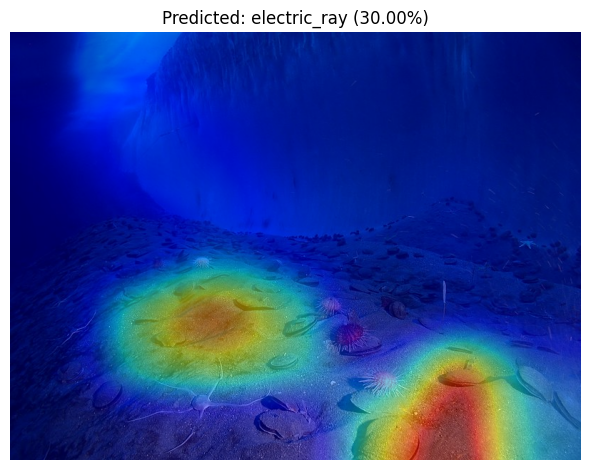

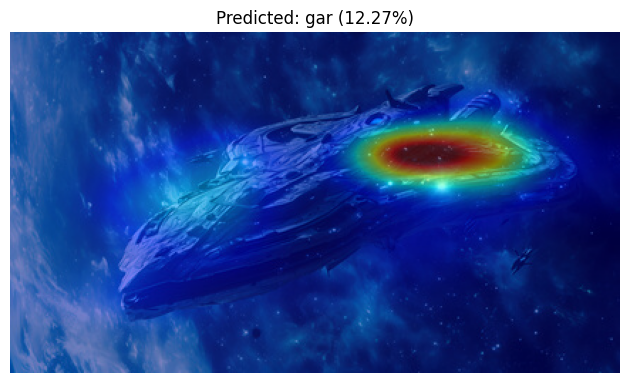

In [50]:
run_cam("admiralbutterfly.jpg", "layer4", 6)
run_cam("stingray.jpeg", "layer4", 321)
run_cam("reef.jpg", "layer4")
run_cam("underwater.jpg", "layer4")
run_cam("spaceship.jpg", "layer4")